<div style="background-color:#F3F2EE">
    <br /><br />
        <p style="text-align: center;">
            <font size="6" color='#0A1781'>
                <strong>
                    NLP Triagem Inteligente Financeira - Data Science Project
                </strong>
              </font>
        </p>
        <p style="text-align: center;">
            <font size="6" color='#C58A1E'>
                <strong>
                    Modeling Baseline | TF-IDF + Logistic Regression
                </strong>
            </font>
        </p>
        <p style="text-align: center;">
            <font size="5" color='#C58A1E'>
                <strong>
                    Treinar e avaliar um baseline supervisionado para classificação textual utilizando TF-IDF<br />e Regressão Logística, estabelecendo uma referência técnica sólida<br />para comparação posterior com modelos mais avançados.
                </strong>
            </font>
        </p>
    <br />
</div>

<div style="background-color:#F3F2EE">
    <p style="text-align: right;">
      <font size="4" color='#444444'>
            Roberto SSoares - LfLngLrnng
      </font>
    </p>
    <p style="text-align: right;"><font size="2" color='#444444'>
        <a href="https://www.linkedin.com/in/roberto-dos-santos-soares/">in/roberto-dos-santos-soares</a><br /><a href="https://roberto-ssoares.github.io/meu-portfolio/">Portifólio: roberto-ssoares</a>
    </p>
    <p style="text-align: right;">
        <font size="4" color='#444444'>
            " [+] Faturamento [-] Custo [+] Qualidade de vida "
        </font>
        <br />
        <font size="2" color='#918e8e'>"Mestre Bruno Jardim"
        </font>
    </p>        
    <p style="text-align: right;">        
        <font size="2" color='#918e8e'>           
        </font>
    </p>
</div>

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 Objetivo:</strong></font>

<font size="2" color='#66666'>

>- **Ações realizadas neste notebook**
    - *Leitura das bases gold de treino, validação e teste*
    - *Definição da variável textual e da variável-alvo*
    - *Construção de pipelines baseline com TF-IDF + Logistic Regression*
    - *Comparação entre configurações candidatas*
    - *Seleção do melhor modelo com base na validação*
    - *Reajuste do modelo final*
    - *Avaliação no conjunto de teste*
    - *Persistência do pipeline, métricas e previsões*

>- **Justificativa técnica**
    - Em projetos de NLP aplicado, o baseline é essencial para estabelecer uma referência confiável antes do uso de modelos mais complexos.
    - Um baseline forte, bem avaliado e bem documentado permite medir ganho real quando avançarmos para transformers.

>- **Resultados esperados**
    - Baseline treinado e validado
    - Melhor configuração selecionada
    - Métricas registradas
    - Erros principais analisados
    - Artefatos persistidos para reuso

---

</font></div>

In [1]:
import warnings
from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>📌 TfidfVectorizer</strong></font>

<font size="2" color='#66666'>

>- Como computadores não "leem" palavras como nós, eles precisam de uma representação numérica para processar dados em algoritmos de Machine Learning.
    - O TfidfVectorizer faz isso calculando a importância de cada palavra através de uma métrica chamada TF-IDF. 

>- Como funciona o TF-IDF?
    - A sigla significa Term Frequency – Inverse Document Frequency e combina dois conceitos: 
    - TF (Term Frequency): 
        - Conta quantas vezes uma palavra aparece em um documento específico. 
        - Quanto mais ela aparece, maior o peso.
    - IDF (Inverse Document Frequency): 
        - Diminui o peso de palavras que aparecem em quase todos os documentos (como "o", "de", "que"), pois elas não ajudam a diferenciar um texto do outro. 
        - Palavras mais raras e específicas ganham um peso maior. 

---
</font></div>

In [2]:
pd.set_option('display.max_colwidth', None)                     # Não limitar a largura da coluna
pd.set_option('display.width', None)                            # Expandir a largura da exibição (evitar quebra de linha horizontal)


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 1. Caminhos de Diretórios</strong></font>

<font size="2" color='#66666'></font></div>

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"

GOLD_DIR = DATA_DIR / "03-gold"
MODELS_DIR = PROJECT_ROOT / "models" / "baseline"
REPORTS_DIR = PROJECT_ROOT / "artifacts" / "reports"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("GOLD_DIR    :", GOLD_DIR)
print("MODELS_DIR  :", MODELS_DIR)
print("REPORTS_DIR :", REPORTS_DIR)
print("FIGURES_DIR :", FIGURES_DIR)


PROJECT_ROOT: D:\_DS-Projects\nlp-triagem-inteligente-financeira
GOLD_DIR    : D:\_DS-Projects\nlp-triagem-inteligente-financeira\data\03-gold
MODELS_DIR  : D:\_DS-Projects\nlp-triagem-inteligente-financeira\models\baseline
REPORTS_DIR : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\reports
FIGURES_DIR : D:\_DS-Projects\nlp-triagem-inteligente-financeira\artifacts\figures


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 2. Leitura das bases gold</strong></font>

<font size="2" color='#66666'>
    
>- Nesta etapa carregamos:
    - treino
    - validação
    - teste
    - mapping de labels

>- Essas bases foram geradas no Notebook 03.
    
</font></div>

In [4]:
train_path = GOLD_DIR / "faq_bacen_gold_train.csv"
valid_path = GOLD_DIR / "faq_bacen_gold_valid.csv"
test_path = GOLD_DIR / "faq_bacen_gold_test.csv"
label_mapping_path = GOLD_DIR / "label_mapping.csv"

train_gold = pd.read_csv(train_path)
valid_gold = pd.read_csv(valid_path)
test_gold = pd.read_csv(test_path)
label_mapping_df = pd.read_csv(label_mapping_path).sort_values("label_id")

print("train_gold:", train_gold.shape)
print("valid_gold:", valid_gold.shape)
print("test_gold :", test_gold.shape)
print("label_mapping_df:", label_mapping_df.shape)


train_gold: (1044, 8)
valid_gold: (261, 8)
test_gold : (373, 8)
label_mapping_df: (242, 2)


In [5]:
train_gold.head()

,question_raw,question_clean_light,question_clean,category_final,label_id,answer,split,model_split
0,O que é unidade de recebíveis?,o que é unidade de recebíveis?,o que e unidade de recebiveis,Operações com Recebíveis Conceitos importantes,154,"É ativo financeiro composto por recebíveis de arranjo de pagamento, inclusive os recebíveis oriundos de operações de antecipação pré-contratadas, caracterizados pelo(a) mesmo(a): a) número de inscrição no Cadastro Nacional da Pessoa Jurídica (CNPJ) ou no Cadastro de Pessoas Físicas (CPF) do usuário final recebedor; b) identificação do arranjo de pagamento; c) identificação da instituição credenciadora ou subcredenciadora; e d) data de liquidação.",train,train
1,O empregado pode abrir uma conta-salário por sua livre iniciativa?,o empregado pode abrir uma conta-salário por sua livre iniciativa?,o empregado pode abrir uma conta salario por sua livre iniciativa,Conta-Salário e Portabilidade Salarial,70,"Não. A conta-salário não é aberta por iniciativa do empregado. É necessário que o empregador contrate um banco para prestar o serviço de pagamento dos salários de seus empregados. O empregador é o responsável pela identificação do beneficiário, devendo encaminhar as informações necessárias à instituição financeira contratada para fins da abertura da conta-salário.",train,train
2,O que é endosso?,o que é endosso?,o que e endosso,Cheques Endosso,58,"O endosso é a transmissão de um cheque a outra pessoa que não o seu beneficiário original, identificado ou não. Por meio do endosso, o beneficiário do cheque transmite todos os seus direitos sobre o cheque a um terceiro, que se torna o novo beneficiário do cheque.",train,train
3,O que é o Programa de Garantia da Atividade Agropecuária (Proagro)?,o que é o programa de garantia da atividade agropecuária (proagro)?,o que e o programa de garantia da atividade agropecuaria proagro,Programa de Garantia da Atividade Agropecuária (Proagro) Informações Gerais,198,"É um programa do governo federal, administrado pelo Banco Central (BC), conforme normas, critérios e condições definidas pelo Conselho Monetário Nacional (CMN), que: permite aos produtores rurais, especialmente pequenos e médios, a exoneração de suas obrigações financeiras relativas a financiamentos de custeio agrícola junto às instituições financeiras; eindeniza os recursos próprios do beneficiário, utilizados em custeio rural, no caso de perdas das receitas, na ocorrência de frustração de safra provocada por eventos adversos de natureza climática ou biológica, tais como: seca, chuva excessiva, geada, granizo, variação excessiva de temperatura, ventos fortes e doenças ou pragas sem método de controle exequível. A regulamentação do Proagro está disponível no capítulo 16 doManual de Crédito Rural (MCR). Um resumo de instruções para o beneficiário, que tem objetivo apenas de orientação, está disponívelaqui.",train,train
4,Quais instituições participam do Open Banking?,quais instituições participam do open banking?,quais instituicoes participam do open banking,Open Banking Informações gerais,151,"Participam do Open Banking somente as instituições financeiras e demais instituições autorizadas a funcionar pelo Banco Central. Entre esse universo de instituições, no entanto, a regulamentação prevê participantes obrigatórios e voluntários, a depender do dado ou serviço que está sendo compartilhado. As demais perguntas dessa Faq detalham esse assunto. Importante! As informações sobre as instituições participantes que fazem parte do escopo de dados do Open Banking deverão ser compartilhados em formato aberto para o acesso pelo público.",train,train


In [6]:
label_ids = label_mapping_df["label_id"].tolist()
label_names = label_mapping_df["category_final"].tolist()

id_to_label = dict(zip(label_mapping_df["label_id"], label_mapping_df["category_final"]))
label_to_id = dict(zip(label_mapping_df["category_final"], label_mapping_df["label_id"]))

print("Número de labels:", len(label_ids))
print("Primeiras labels:", label_names[:10])

Número de labels: 242
Primeiras labels: ['Acordo Administrativo em Processo de Supervisão (APS)', 'Alerta contra golpes envolvendo o nome do Banco Central e de instituições financeiras', 'Aplicações financeiras', 'Arranjos de Pagamentos Compras e relações de consumo', 'Arranjos de Pagamentos Conceitos importantes', 'Arranjos de Pagamentos Informações Gerais', 'Arranjos de Pagamentos Interoperabilidade, liquidação centralizada e compulsório', 'Arranjos de Pagamentos Supervisão dos arranjos pelo BC', 'Atendimento bancário (fila, feriados e outros)', 'Bacen Jud e SISBAJUD Informações gerais']


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 3. Definição das variáveis de modelagem</strong></font>

<font size="2" color='#66666'>
    
>- Para o baseline, usaremos:
    - `question_clean` como variável textual
    - `label_id` como target numérico

>- A coluna `question_raw` permanece importante para análises qualitativas, mas o treino clássico será realizado sobre a versão limpa.
    
</font></div>

In [7]:
TEXT_COL = "question_clean"
TARGET_COL = "label_id"

X_train = train_gold[TEXT_COL].fillna("")
y_train = train_gold[TARGET_COL]

X_valid = valid_gold[TEXT_COL].fillna("")
y_valid = valid_gold[TARGET_COL]

X_test = test_gold[TEXT_COL].fillna("")
y_test = test_gold[TARGET_COL]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


X_train: (1044,)
y_train: (1044,)
X_valid: (261,)
y_valid: (261,)
X_test : (373,)
y_test : (373,)


In [8]:
train_gold[[TEXT_COL, "category_final", TARGET_COL]].sample(5, random_state=42)

,question_clean,category_final,label_id
971,e necessario emitir boleto de pagamento para realizacao da portabilidade,Portabilidade de Crédito Procedimentos,176
280,onde posso consultar os escritorios de representacao de instituicoes financeiras estrangeiras,Processos de Autorização do Banco Central Informações Gerais,189
536,posso obter um emprestimo em uma cooperativa de credito,SEM-CATEGORIA,217
824,com que frequencia as instituicoes deverao enviar as informacoes de valores a receber,Valores a Receber,241
644,quero abrir uma conta no exterior como faco,Contas de brasileiros no exterior e de estrangeiros no Brasil Contas de brasileiros no exterior,71


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 4. Estratégia do baseline</strong></font>

<font size="2" color='#66666'>
    
>- Vamos comparar duas configurações simples e fortes:
    - **Configuração A**
        - TF-IDF com unigramas
    - **Configuração B**
        - TF-IDF com unigramas e bigramas
    - Em ambas:
        - Regressão Logística com solver adequado para classificação multiclasse
        - balanceamento por classe
        - número elevado de iterações para convergência
    
</font></div>

In [9]:
candidate_configs = [
    {
        "name": "tfidf_word_unigram_logreg",
        "tfidf_params": {
            "analyzer": "word",
            "ngram_range": (1, 1),
            "min_df": 2,
            "max_df": 0.95,
            "sublinear_tf": True,
        },
        "logreg_params": {
            "C": 2.0,
            "max_iter": 3000,
            "solver": "saga",
            "class_weight": "balanced",
            "random_state": 42,
        },
    },
    {
        "name": "tfidf_word_unigram_bigram_logreg",
        "tfidf_params": {
            "analyzer": "word",
            "ngram_range": (1, 2),
            "min_df": 2,
            "max_df": 0.95,
            "sublinear_tf": True,
        },
        "logreg_params": {
            "C": 2.0,
            "max_iter": 3000,
            "solver": "saga",
            "class_weight": "balanced",
            "random_state": 42,
        },
    },
]

candidate_configs

[{'name': 'tfidf_word_unigram_logreg',
  'tfidf_params': {'analyzer': 'word',
   'ngram_range': (1, 1),
   'min_df': 2,
   'max_df': 0.95,
   'sublinear_tf': True},
  'logreg_params': {'C': 2.0,
   'max_iter': 3000,
   'solver': 'saga',
   'class_weight': 'balanced',
   'random_state': 42}},
 {'name': 'tfidf_word_unigram_bigram_logreg',
  'tfidf_params': {'analyzer': 'word',
   'ngram_range': (1, 2),
   'min_df': 2,
   'max_df': 0.95,
   'sublinear_tf': True},
  'logreg_params': {'C': 2.0,
   'max_iter': 3000,
   'solver': 'saga',
   'class_weight': 'balanced',
   'random_state': 42}}]

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 5. Funções auxiliares</strong></font>

<font size="2" color='#66666'>
    
- Nesta etapa definimos funções para:
    - *construir o pipeline*
    - *avaliar métricas*
    - *transformar o classification report em DataFrame*
    
</font></div>

In [10]:
def build_baseline_pipeline(tfidf_params: dict, logreg_params: dict) -> Pipeline:
    return Pipeline(
        steps=[
            ("tfidf", TfidfVectorizer(**tfidf_params)),
            ("clf", LogisticRegression(**logreg_params)),
        ]
    )


def compute_metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def build_report_df(y_true, y_pred, labels, target_names) -> pd.DataFrame:
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).T
   

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 6 Treino e comparação das configurações no conjunto de validação</strong></font>

<font size="2" color='#66666'></font></div>

In [11]:
%%time

model_registry = {}
valid_results = []

for config in candidate_configs:
    name = config["name"]
    print(f"Treinando: {name}")

    # Modelo
    model = build_baseline_pipeline(
        tfidf_params=config["tfidf_params"],
        logreg_params=config["logreg_params"],
    )

    # Treinamento
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    metrics = compute_metrics(y_valid, valid_pred)
    
    valid_results.append(
        {
            "model_name": name,
            **metrics,
        }
    )
    
    model_registry[name] = {
        "config": config,
        "model": model,
        "valid_pred": valid_pred,
        "valid_metrics": metrics,
    }

valid_results_df = pd.DataFrame(valid_results).sort_values(
    by=["macro_f1", "weighted_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

valid_results_df


Treinando: tfidf_word_unigram_logreg
Treinando: tfidf_word_unigram_bigram_logreg
CPU times: total: 1min 42s
Wall time: 2min 10s


,model_name,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,tfidf_word_unigram_logreg,0.310345,0.224697,0.289012,0.235980,0.255121
1,tfidf_word_unigram_bigram_logreg,0.256705,0.186703,0.250611,0.199029,0.207195


In [12]:
valid_results_df.style.format(
    {
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
    }
)

,model_name,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,tfidf_word_unigram_logreg,0.3103,0.2247,0.2890,0.2360,0.2551
1,tfidf_word_unigram_bigram_logreg,0.2567,0.1867,0.2506,0.1990,0.2072


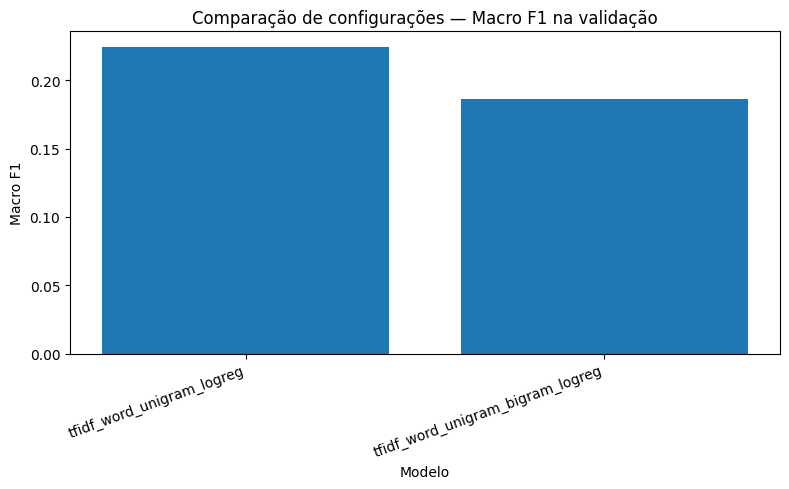

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(valid_results_df["model_name"], valid_results_df["macro_f1"])
plt.title("Comparação de configurações — Macro F1 na validação")
plt.ylabel("Macro F1")
plt.xlabel("Modelo")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 7. Seleção do melhor baseline</strong></font>

<font size="2" color='#66666'>

>- O critério principal será:
    - **Macro F1 na validação**

>- Essa escolha é adequada porque:
    - ***considera desempenho entre classes***
    - ***penaliza melhor cenários com desbalanceamento***
    - ***evita olhar apenas accuracy***

---
</font></div>


In [14]:
best_model_name = valid_results_df.iloc[0]["model_name"]
best_entry = model_registry[best_model_name]

best_model_name, best_entry["valid_metrics"]

('tfidf_word_unigram_logreg',
 {'accuracy': 0.3103448275862069,
  'macro_f1': 0.2246974079704937,
  'weighted_f1': 0.2890115669020334,
  'macro_precision': 0.2359803139132748,
  'macro_recall': 0.25512104283054005})

In [16]:
valid_pred_best = best_entry["valid_pred"]

valid_report_df = build_report_df(
    y_true=y_valid,
    y_pred=valid_pred_best,
    labels=label_ids,
    target_names=label_names,
)

valid_report_df.head(12)


,precision,recall,f1-score,support
Acordo Administrativo em Processo de Supervisão (APS),0.666667,0.666667,0.666667,3.0
Alerta contra golpes envolvendo o nome do Banco Central e de instituições financeiras,0.000000,0.000000,0.000000,0.0
Aplicações financeiras,0.000000,0.000000,0.000000,2.0
Arranjos de Pagamentos Compras e relações de consumo,0.000000,0.000000,0.000000,0.0
Arranjos de Pagamentos Conceitos importantes,0.000000,0.000000,0.000000,0.0
Arranjos de Pagamentos Informações Gerais,0.000000,0.000000,0.000000,0.0
"Arranjos de Pagamentos Interoperabilidade, liquidação centralizada e compulsório",0.000000,0.000000,0.000000,0.0
Arranjos de Pagamentos Supervisão dos arranjos pelo BC,0.500000,1.000000,0.666667,1.0
"Atendimento bancário (fila, feriados e outros)",0.000000,0.000000,0.000000,1.0
Bacen Jud e SISBAJUD Informações gerais,0.000000,0.000000,0.000000,0.0


In [17]:
valid_class_report = valid_report_df.loc[label_names].copy()
valid_class_report = valid_class_report.sort_values(by="f1-score", ascending=False)

valid_class_report.head(12)

,precision,recall,f1-score,support
Cadastro Positivo Solicitação de cancelamento ou suspensão do cadastro positivo,1.0,1.0,1.0,2.0
Cadastro Positivo Nota do cadastro positivo,1.0,1.0,1.0,1.0
Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Informações gerais,1.0,1.0,1.0,1.0
Contas de brasileiros no exterior e de estrangeiros no Brasil Contas no Brasil de residentes no exterior,1.0,1.0,1.0,1.0
Cheques Endosso,1.0,1.0,1.0,1.0
"Correspondentes no País (lotéricas, banco postal e outros)",1.0,1.0,1.0,1.0
Consórcios Obrigações financeiras dos consorciados,1.0,1.0,1.0,2.0
Cheque especial Uso do limite de Cheque Especial,1.0,1.0,1.0,1.0
Solicitação de Relatórios Sigilosos referentes a pessoa falecida ou desaparecida,1.0,1.0,1.0,1.0
Microcrédito Microcrédito,1.0,1.0,1.0,1.0


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 8. Top classes mais frequentes</strong></font>

<font size="2" color='#66666'></font></div>

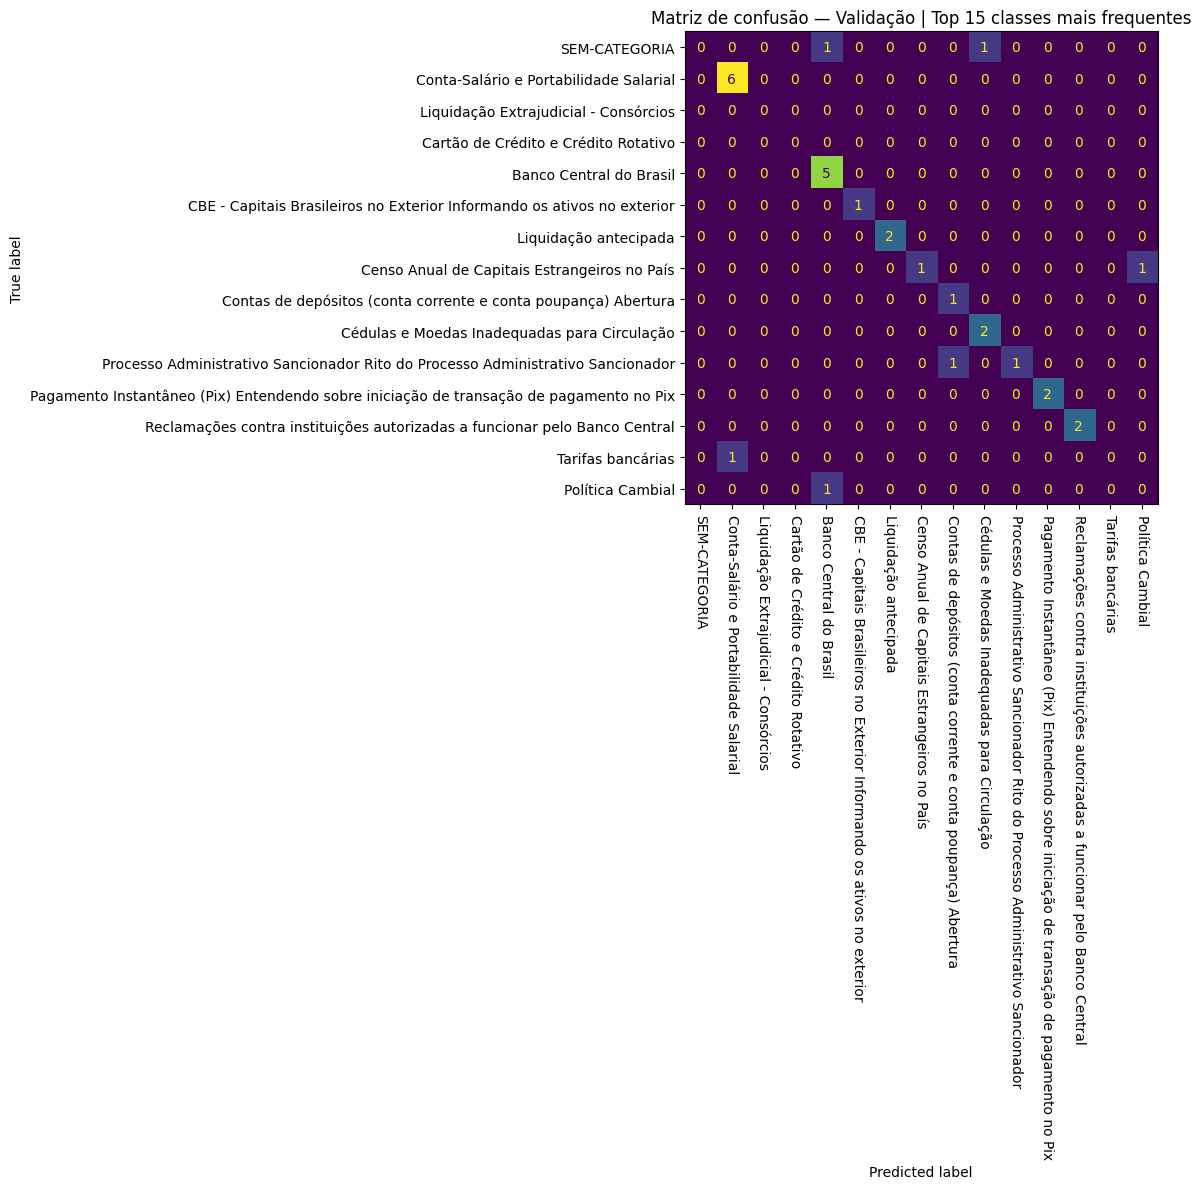

In [29]:
TOP_N = 15

top_valid_labels = (
    valid_gold["category_final"]
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)

top_valid_label_ids = [label_to_id[label] for label in top_valid_labels]

valid_mask_top = valid_gold["label_id"].isin(top_valid_label_ids)

y_valid_top = y_valid[valid_mask_top]
valid_pred_top = pd.Series(valid_pred_best, index=valid_gold.index)[valid_mask_top]

cm_valid_top = confusion_matrix(
    y_valid_top,
    valid_pred_top,
    labels=top_valid_label_ids
)

fig, ax = plt.subplots(figsize=(16, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_valid_top,
    display_labels=top_valid_labels
)

disp.plot(ax=ax, xticks_rotation=-90, colorbar=False)
plt.title(f"Matriz de confusão — Validação | Top {TOP_N} classes mais frequentes")
plt.tight_layout()
plt.show()


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 9. Matriz normalizada</strong></font>

<font size="2" color='#66666'></font></div>

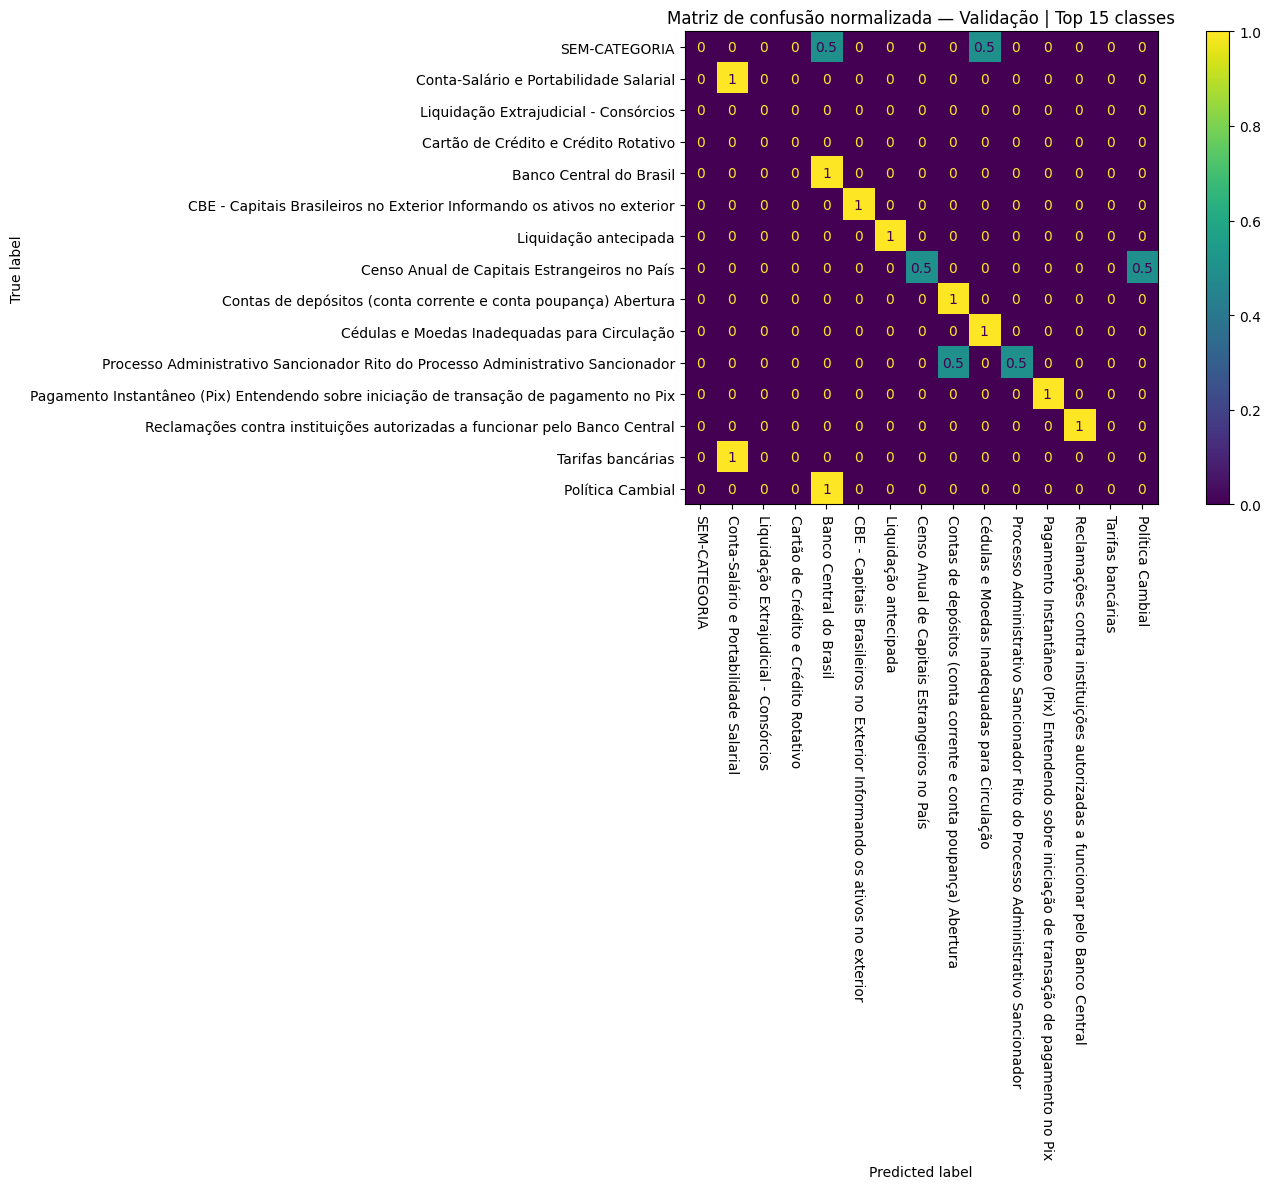

In [28]:
cm_valid_top_norm = confusion_matrix(
    y_valid_top,
    valid_pred_top,
    labels=top_valid_label_ids,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(16, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_valid_top_norm,
    display_labels=top_valid_labels
)
disp.plot(ax=ax, xticks_rotation=-90, colorbar=True)
plt.title(f"Matriz de confusão normalizada — Validação | Top {TOP_N} classes")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 9. Classes com pior recall</strong></font>

<font size="2" color='#66666'></font></div>


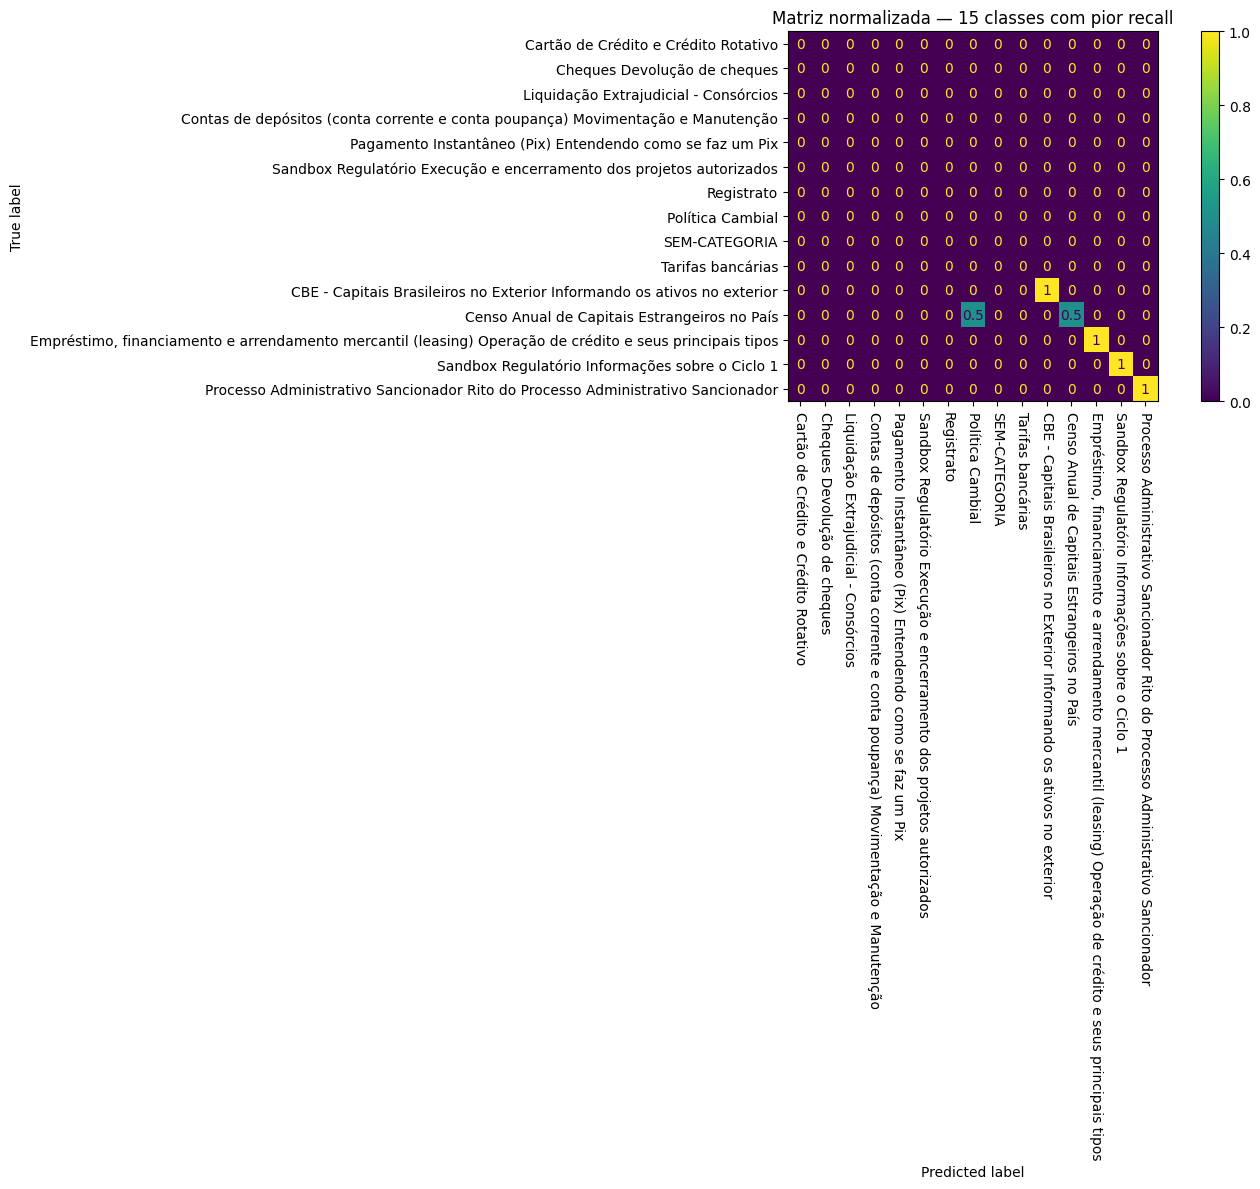

In [30]:
valid_class_report = valid_report_df.loc[label_names].copy()
valid_class_report["support"] = valid_class_report["support"].astype(float)

MIN_SUPPORT = 3
WORST_N = 15

worst_classes = (
    valid_class_report[valid_class_report["support"] >= MIN_SUPPORT]
    .sort_values(by="recall", ascending=True)
    .head(WORST_N)
    .index
    .tolist()
)

worst_label_ids = [label_to_id[label] for label in worst_classes]

valid_mask_worst = valid_gold["label_id"].isin(worst_label_ids)

y_valid_worst = y_valid[valid_mask_worst]
valid_pred_worst = pd.Series(valid_pred_best, index=valid_gold.index)[valid_mask_worst]

cm_valid_worst = confusion_matrix(
    y_valid_worst,
    valid_pred_worst,
    labels=worst_label_ids,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(16, 12))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_valid_worst,
    display_labels=worst_classes
)
disp.plot(ax=ax, xticks_rotation=-90, colorbar=True)
plt.title(f"Matriz normalizada — {WORST_N} classes com pior recall")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 10. Análise inicial dos erros de validação</strong></font>

<font size="2" color='#66666'>
    
>- Vamos inspecionar previsões incorretas para entender:
    - classes confundidas
    - exemplos ambíguos
    - limites do baseline

</font></div>

In [32]:
valid_errors = valid_gold.copy()
valid_errors["y_true"] = y_valid.values
valid_errors["y_pred"] = valid_pred_best
valid_errors["true_label"] = valid_errors["y_true"].map(id_to_label)
valid_errors["pred_label"] = valid_errors["y_pred"].map(id_to_label)
valid_errors["is_error"] = valid_errors["y_true"] != valid_errors["y_pred"]

valid_errors = valid_errors[valid_errors["is_error"]].copy()

print("Quantidade de erros na validação:", valid_errors.shape[0])
valid_errors[["question_raw", "true_label", "pred_label"]].head(12)

Quantidade de erros na validação: 180


,question_raw,true_label,pred_label
0,"Segundo a natureza das garantias, como devem ser utilizados os títulos de crédito rural?",Crédito Rural Assistência Técnica e Garantias,Crédito Rural Liberação dos recursos financeiros e pagamento para operações com recursos controlados
1,O que o investidor deve fazer?,Liquidação Extrajudicial - Corretoras de Títulos e Valores Mobiliários,Processos de Autorização do Banco Central Processo de autorização para constituição e funcionamento – Administradoras de Consórcio
2,O que é o Bacen Jud?,SEM-CATEGORIA,Cheques Emissão
4,Instituições de pagamento podem realizar atividades de instituições financeiras?,SEM-CATEGORIA,Instituições de Pagamento
5,O que é necessário para abrir uma conta de depósitos?,Contas de depósitos (conta corrente e conta poupança) Abertura,Contas de depósitos (conta corrente e conta poupança) Informações gerais
7,Como são validados os atos processuais em meio eletrônico?,Processo Administrativo Sancionador Rito do Processo Administrativo Sancionador,Cédulas manchadas de tinta
8,Posso fazer um Pix Agendado por meio de um iniciador?,Pagamento Instantâneo (Pix) Entendendo sobre iniciação de transação de pagamento no Pix,Pagamento Instantâneo (Pix) Entendendo quem pode usar o Pix e como usar o Pix
9,"Já quitei minha dívida, mas o meu nome não saiu do SCR. Por quê?",Sistema de Informações de Créditos (SCR) Atualização dos dados,Crédito Rural Renegociação das dívidas
10,Como faço para habilitar meu crédito? Serei avisado sobre isso? De que forma?,Liquidação Extrajudicial - Consórcios,Empréstimos consignados Cartão de crédito consignado
12,Possuo uma empresa no exterior juntos com outros sócios. Declaro o valor total ou apenas minha parcela?,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Empréstimos


In [33]:
error_pairs = (
    valid_errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

error_pairs.head(12)

,true_label,pred_label,count
131,SEM-CATEGORIA,Cheques Compensação e pagamento,3
41,Consórcios Grupo de consórcio,Consórcios Consórcios - Informações gerais,2
120,Registrato,Open Banking Segurança dos dados pessoais compartilhados,2
148,SEM-CATEGORIA,Pagamento Instantâneo (Pix) Entendendo quem pode usar o Pix e como usar o Pix,2
20,Cartão de Crédito Internacional,Importações Pagamento das importações,2
169,Termo de Compromisso Após a celebração do Termo de Compromisso,Termo de Compromisso Informações gerais,2
6,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Crédito Rural Renegociação das dívidas,1
7,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Empréstimos,1
8,CBE - Capitais Brasileiros no Exterior Iniciando a declaração,Envio e recebimento de recursos em moeda estrangeira,1
5,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Cheques Emissão,1


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 11. Tabela dos pares de confusão</strong></font>

<font size="2" color='#66666'></font></div>

In [37]:
top_confusions = (
    valid_errors.groupby(["true_label", "pred_label"])
    .size()
    .reset_index(name="count")
    .query("true_label != pred_label")
    .sort_values("count", ascending=False)
    .head(12)
)

top_confusions

,true_label,pred_label,count
131,SEM-CATEGORIA,Cheques Compensação e pagamento,3
41,Consórcios Grupo de consórcio,Consórcios Consórcios - Informações gerais,2
120,Registrato,Open Banking Segurança dos dados pessoais compartilhados,2
148,SEM-CATEGORIA,Pagamento Instantâneo (Pix) Entendendo quem pode usar o Pix e como usar o Pix,2
20,Cartão de Crédito Internacional,Importações Pagamento das importações,2
169,Termo de Compromisso Após a celebração do Termo de Compromisso,Termo de Compromisso Informações gerais,2
6,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Crédito Rural Renegociação das dívidas,1
7,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Empréstimos,1
8,CBE - Capitais Brasileiros no Exterior Iniciando a declaração,Envio e recebimento de recursos em moeda estrangeira,1
5,CBE - Capitais Brasileiros no Exterior Informando os ativos no exterior,Cheques Emissão,1


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 8.2. Gráfico dos maiores erros</strong></font>

<font size="2" color='#66666'></font></div>

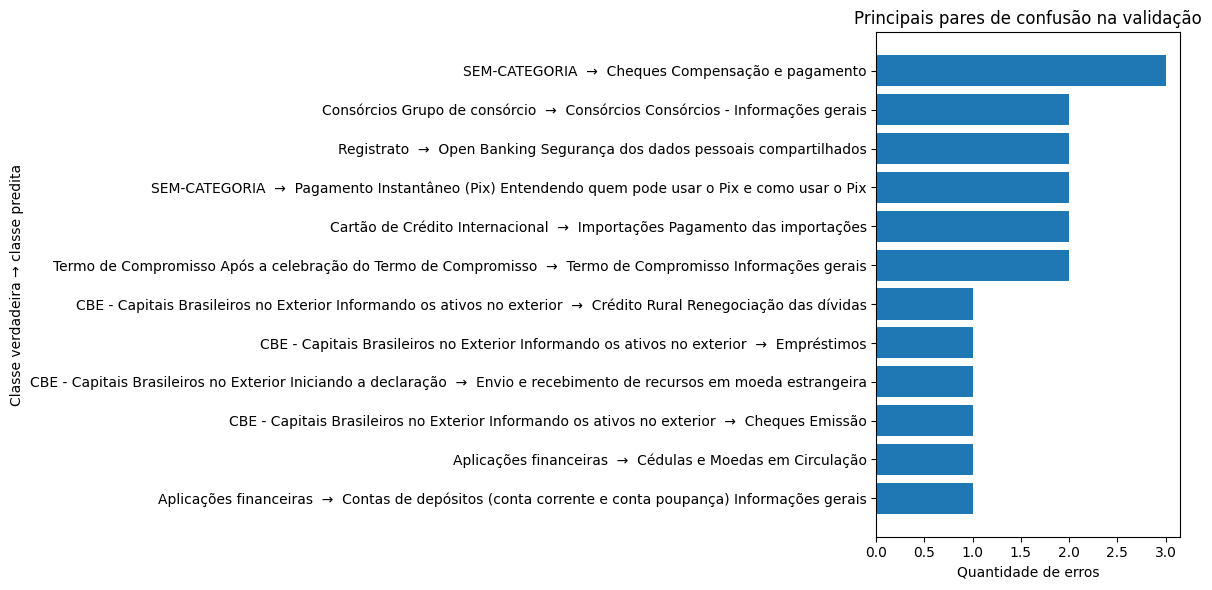

In [40]:
plt.figure(figsize=(12, 6))
plt.barh(
    (top_confusions["true_label"] + "  →  " + top_confusions["pred_label"])[::-1],
    top_confusions["count"][::-1]
)
plt.title("Principais pares de confusão na validação")
plt.xlabel("Quantidade de erros")
plt.ylabel("Classe verdadeira → classe predita")
plt.tight_layout()
plt.show()

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 9. Reajuste do modelo final</strong></font>

<font size="2" color='#66666'>
    
>- Após escolher a melhor configuração com base na validação, vamos reajustar o pipeline usando:
    - treino + validação

>- Em seguida, avaliaremos o desempenho final no conjunto de teste.

</font></div>

In [41]:
train_valid_gold = pd.concat([train_gold, valid_gold], ignore_index=True)

X_train_valid = train_valid_gold[TEXT_COL].fillna("")
y_train_valid = train_valid_gold[TARGET_COL]

final_model = build_baseline_pipeline(
    tfidf_params=best_entry["config"]["tfidf_params"],
    logreg_params=best_entry["config"]["logreg_params"],
)

final_model.fit(X_train_valid, y_train_valid)

print("Modelo final reajustado com treino + validação.")

Modelo final reajustado com treino + validação.


In [42]:
test_pred = final_model.predict(X_test)

test_metrics = compute_metrics(y_test, test_pred)
test_metrics

{'accuracy': 0.30294906166219837,
 'macro_f1': 0.23681279636053504,
 'weighted_f1': 0.3028420789814892,
 'macro_precision': 0.25571907154821727,
 'macro_recall': 0.2639985642498205}

In [43]:
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.style.format(
    {
        "accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}",
        "macro_precision": "{:.4f}",
        "macro_recall": "{:.4f}",
    }
)

,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,0.3029,0.2368,0.3028,0.2557,0.2640


In [44]:
test_report_df = build_report_df(
    y_true=y_test,
    y_pred=test_pred,
    labels=label_ids,
    target_names=label_names,
)

test_class_report = test_report_df.loc[label_names].copy()
test_class_report = test_class_report.sort_values(by="f1-score", ascending=False)

test_class_report.head(12)

,precision,recall,f1-score,support
Cadastro Informativo de créditos não quitados do setor público federal (Cadin) Exclusão dos dados do Cadin,1.0,1.0,1.0,1.0
CBE - Capitais Brasileiros no Exterior Obrigatoriedade da declaração,1.0,1.0,1.0,2.0
Cadastro de Clientes do Sistema Financeiro Nacional (CCS) Dados do CCS,1.0,1.0,1.0,3.0
Cartão de Crédito Internacional,1.0,1.0,1.0,1.0
Empréstimos consignados Cartão de crédito consignado,1.0,1.0,1.0,1.0
Consórcios Aquisição de bens e serviços,1.0,1.0,1.0,2.0
Crédito Rural Renegociação das dívidas,1.0,1.0,1.0,1.0
Crédito Rural Monitoramento e Fiscalização,1.0,1.0,1.0,1.0
Empréstimos consignados Principais dúvidas,1.0,1.0,1.0,2.0
Empréstimos consignados Margem Consignável,1.0,1.0,1.0,1.0


In [ ]:
cm_test = confusion_matrix(y_test, test_pred, labels=label_ids)

fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=-90, colorbar=False)
plt.title(f"Matriz de confusão — Teste | {best_model_name}")
plt.tight_layout()
plt.show()

In [46]:
test_gold.head(3)

,question_raw,question_clean_light,question_clean,category_final,label_id,answer,split,model_split
0,Qual a diferença entre credenciadores e subcredenciadores?,qual a diferença entre credenciadores e subcredenciadores?,qual a diferenca entre credenciadores e subcredenciadores,Instituições de Pagamento,132,"Credenciadoras e subcredenciadoras são instituições que habilitam estabelecimentos comerciais a aceitarem instrumentos de pagamentos, como cartões de crédito e débito no âmbito do arranjo de pagamento em que atuam. Enquanto as credenciadoras atuam diretamente ligadas às instituições emissoras dos cartões, as subcredenciadoras atuam por meio das credenciadoras.",test,test
1,O cliente pode revogar o consentimento anterior?,o cliente pode revogar o consentimento anterior?,o cliente pode revogar o consentimento anterior,Open Banking Autorização do cliente para compartilhamento de seus dados,147,"Sim, as instituições participantes envolvidas no compartilhamento de dados ou serviços devem assegurar ao cliente a possibilidade da revogação do respectivo consentimento, a qualquer tempo, por meio de procedimento seguro, ágil, preciso e conveniente. Essa revogação deve ser efetuada com base nos seguintes prazos: em até um dia, contado a partir da solicitação do cliente, no caso de iniciação de transação de pagamento; oude forma imediata, para os demais casos. As instituições receptoras de dados ou iniciadoras de transação de pagamento devem disponibilizar ao cliente a opção da revogação de consentimento ao menos pelo mesmo canal de atendimento no qual foi concedido, caso ainda existente. Atenção!As instituições transmissoras de dados ou detentoras de conta estão proibidas de propor ao cliente a revogação de seu consentimento, exceto em caso de suspeita de fraude.",test,test
2,O que devo fazer se suspeitar que uma cédula pode ser falsa?,o que devo fazer se suspeitar que uma cédula pode ser falsa?,o que devo fazer se suspeitar que uma cedula pode ser falsa,"Cédula de R$200,00 Itens de segurança e falsificações",99,"Você deve conferir os principais itens de segurança e, se possível, comparar a nota com outras de mesmo desenho. Se ainda assim suspeitar de nota falsa, você deve recusá-la. Se, sem perceber, você já tiver recebido uma nota suspeita, não a passe adiante. A falsificação é crime previsto no artigo 289 do Código Penal. Encaminhe a nota para exame na rede bancária, solicitando o recibo de retenção. Mais informações podem ser consultadas na páginaCédulas Falsas e Suspeitas.",test,test


In [51]:
TOP_N = 12

top_test_labels = (
    test_gold["category_final"]
    .value_counts()
    .head(TOP_N)
    .index
    .tolist()
)

top_test_label_ids = [label_to_id[label] for label in top_test_labels]

test_mask_top = test_gold["label_id"].isin(top_test_label_ids)

y_test_top = y_test[test_mask_top]
test_pred_top = pd.Series(test_report_df, index=test_gold.index)[test_mask_top]

cm_test = confusion_matrix(
    y_test_top,
    test_pred_top,
    labels=top_test_label_ids
)

fig, ax = plt.subplots(figsize=(16, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_top,
    display_labels=top_test_labels
)

disp.plot(ax=ax, xticks_rotation=-90, colorbar=False)
plt.title(f"Matriz de confusão — Test | Top {TOP_N} classes mais frequentes")
plt.tight_layout()
plt.show()


ValueError: Length of values (245) does not match length of index (373)

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 10. Persistência dos artefatos</strong></font>

<font size="2" color='#66666'>
    
>- Nesta etapa salvamos:
    - pipeline final
    - comparação entre candidatos
    - métricas do teste
    - relatório por classe
    - previsões do teste
    - metadados do baseline

</font></div>

In [ ]:
model_path = MODELS_DIR / "tfidf_logreg_pipeline.joblib"
valid_results_path = REPORTS_DIR / "baseline_valid_model_comparison.csv"
test_metrics_path = REPORTS_DIR / "baseline_test_metrics.csv"
test_report_path = REPORTS_DIR / "baseline_test_classification_report.csv"
test_predictions_path = REPORTS_DIR / "baseline_test_predictions.csv"
metadata_path = MODELS_DIR / "baseline_metadata.json"

joblib.dump(final_model, model_path)

valid_results_df.to_csv(valid_results_path, index=False)
test_metrics_df.to_csv(test_metrics_path, index=False)
test_class_report.to_csv(test_report_path)
test_predictions_df.to_csv(test_predictions_path, index=False)

baseline_metadata = {
    "project": "nlp-triagem-inteligente-financeira",
    "model_family": "TF-IDF + Logistic Regression",
    "selected_model_name": best_model_name,
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "n_train": int(train_gold.shape[0]),
    "n_valid": int(valid_gold.shape[0]),
    "n_test": int(test_gold.shape[0]),
    "n_train_valid": int(train_valid_gold.shape[0]),
    "label_count": int(len(label_ids)),
    "valid_metrics_selected_model": best_entry["valid_metrics"],
    "test_metrics": test_metrics,
    "tfidf_params": best_entry["config"]["tfidf_params"],
    "logreg_params": best_entry["config"]["logreg_params"],
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(baseline_metadata, f, ensure_ascii=False, indent=2)

print("Artefatos salvos com sucesso:")
print(model_path)
print(valid_results_path)
print(test_metrics_path)
print(test_report_path)
print(test_predictions_path)
print(metadata_path)

<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ 11. Leitura executiva do baseline</strong></font>

<font size="2" color='#66666'>
    
>- **Síntese**
    - O baseline com TF-IDF + Regressão Logística estabeleceu uma referência técnica consistente para o projeto, permitindo comparar configurações, selecionar o melhor pipeline e medir desempenho em teste.

>- **Leitura analítica**
    - O modelo apresenta melhor comportamento nas classes mais frequentes, mas encontra dificuldade em categorias semanticamente próximas e em classes menos representadas, o que é esperado em problemas multiclasses com taxonomia extensa.

>- **Valor para o projeto**
    - Este baseline cumpre três papéis:
        - referência quantitativa para comparação com transformer
        - primeiro modelo reutilizável para API
        - evidência de maturidade metodológica no pipeline de NLP

</font></div>


<div style="background-color:#f3f2ee">
    
<font size="4" color='#CC403E'><strong>✔️ Próximo passo</strong></font>

<font size="2" color='#66666'>
    
>- No **Notebook 05 — Transformer Text Classifier**, vamos avaliar um modelo baseado em transformer para medir o ganho real sobre este baseline clássico, especialmente em:
    - classes semanticamente próximas
    - generalização
    - qualidade global da classificação

</font></div>